## Quick check on dynamics of PA site

The simulation must meet these criteria: 

* Canopy trees must grow around 1cm per year
* Trees should reach 100cm DBH after 100  years
* Size distributions are linear on a log log scale
* Biomass is in line with GEDI observations
* Realistic successional dynamics
* Co-existence
* Germination rates should be in line recruitment rates from temperate ForestGEO plots

### Libraries

In [1]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### Load FATES

In [2]:
# fates_params_2pfts_PA_nat_v6.nc
#fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_AD_spinup_v6.Ea8fbc2fc28-F7aa80c14.2025-06-12/run/PA_AD_spinup_v6.Ea8fbc2fc28-F7aa80c14.2025-06-12.sofar.nc'

# /global/homes/j/jneedham/FATES-MRV/param_files/v6/fates_params_PA_nat_v3.nc
#fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_AD_spinup_v6_v3.Ea8fbc2fc28-Ff46de7a5.2025-06-14/run/PA_AD_spinup_v6_v3.Ea8fbc2fc28-Ff46de7a5.2025-06-14.sofar.nc'

# /global/homes/j/jneedham/FATES-MRV/param_files/v6/fates_params_PA_nat_v4.nc
#fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_AD_spinup_v6_v4.Ea8fbc2fc28-Ff46de7a5.2025-06-14/run/PA_AD_spinup_v6_v4.Ea8fbc2fc28-Ff46de7a5.2025-06-14.sofar.nc'

# /global/homes/j/jneedham/FATES-MRV/param_files/v6/fates_params_PA_nat_v5.nc
#fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_AD_spinup_v6_v5.Ea8fbc2fc28-Ff46de7a5.2025-06-14/run/PA_AD_spinup_v6_v5.Ea8fbc2fc28-Ff46de7a5.2025-06-14.sofar.nc'

# /global/homes/j/jneedham/FATES-MRV/param_files/v6/fates_params_PA_nat_v6.nc
#fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_AD_spinup_v6_v6.Ea8fbc2fc28-Ff46de7a5.2025-06-15/run/PA_AD_spinup_v6_v6.Ea8fbc2fc28-Ff46de7a5.2025-06-15.sofar.nc'

# /global/homes/j/jneedham/FATES-MRV/param_files/v6/fates_params_PA_nat_v7.nc
#fates =  '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_AD_spinup_v6_v7.Ea8fbc2fc28-Ff46de7a5.2025-06-15/run/PA_AD_spinup_v6_v7.Ea8fbc2fc28-Ff46de7a5.2025-06-15.sofar.nc'

# /global/homes/j/jneedham/FATES-MRV/param_files/v6/fates_params_PA_nat_v8.nc
#fates =  '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_AD_spinup_v6_v8.Ea8fbc2fc28-Ff46de7a5.2025-06-15/run/PA_AD_spinup_v6_v8.Ea8fbc2fc28-Ff46de7a5.2025-06-15.sofar.nc'

# /global/homes/j/jneedham/FATES-MRV/param_files/v6/fates_params_PA_nat_v9.nc
#fates =  '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_AD_spinup_v6_v9.Ea8fbc2fc28-Ff46de7a5.2025-06-16/run/PA_AD_spinup_v6_v9.Ea8fbc2fc28-Ff46de7a5.2025-06-16.sofar.nc'

# /global/homes/j/jneedham/FATES-MRV/param_files/v6/fates_params_PA_nat_v10.nc
#fates  = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_AD_spinup_v6_v10.Ea8fbc2fc28-Ff46de7a5.2025-06-16/run/PA_AD_spinup_v6_v10.Ea8fbc2fc28-Ff46de7a5.2025-06-16.sofar.nc'

# /global/homes/j/jneedham/FATES-MRV/param_files/v6/fates_params_PA_nat_v11.nc
#fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_AD_spinup_v6_v11.Ea8fbc2fc28-Ff46de7a5.2025-06-16/run/PA_AD_spinup_v6_v11.Ea8fbc2fc28-Ff46de7a5.2025-06-16.sofar.nc'

# /global/homes/j/jneedham/FATES-MRV/param_files/v6/fates_params_PA_nat_v12.nc
fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_AD_spinup_v6_v12.Ea8fbc2fc28-Ff46de7a5.2025-06-16/run/PA_AD_spinup_v6_v12.Ea8fbc2fc28-Ff46de7a5.2025-06-16.sofar.nc'

fates = xr.open_dataset(fates)

In [3]:
nyears = int(len(fates.variables['time'])/12)
print(nyears)
time = np.arange(0,len(fates.variables['time']),1)/12

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

cohort_size_bins = fates.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
#print(cohort_size_bins)
print(nsizebins)
patch_age_bins = fates.variables['fates_levage'][:]

decomp_bins = fates.variables['levdcmp']

100
17


### AGB 

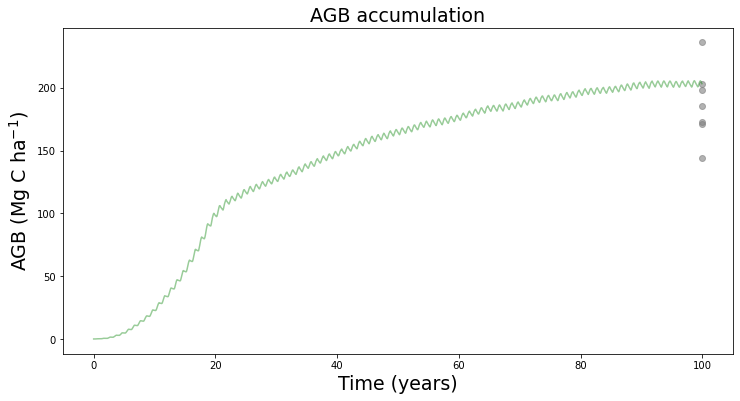

In [4]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, AGB, color='green', label = 'FATES', alpha = 0.4)    
f1ax0.set_title(r'AGB accumulation', fontsize = 19)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    

gedi_x = [100,100,100,100,100,100,100]
gedi_y = [171.59, 172.45, 185.59, 143.95, 203.19, 198.31, 236.16] # Mg ha-1 - aboveground biomass density 

f1ax0.scatter(gedi_x, gedi_y, alpha=0.6, color='grey')

###  Size  distribution 

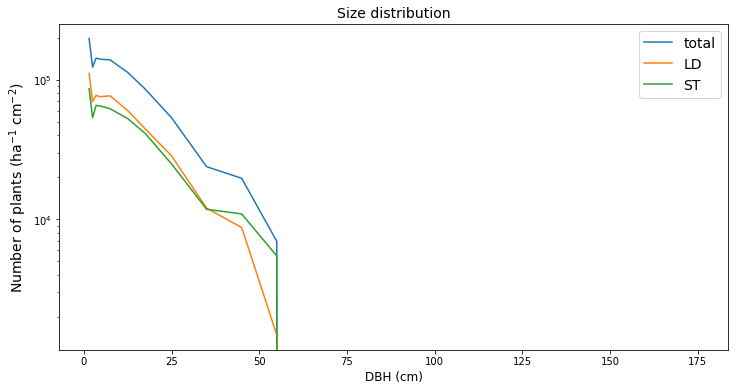

In [5]:
# size bins are LOWER bounds. Remove the fist bin - but add an extra bin to catch trees over last bin edge
cohort_size_bins_ex = np.append(cohort_size_bins[1:], 250)
fates_sizebin_mids = (cohort_size_bins_ex[0:-1] + cohort_size_bins_ex[1:])/2
fates_sizebin_widths = cohort_size_bins_ex[1:] - cohort_size_bins_ex[:-1]

NPLANT_SZPF = fa.scpf_to_scls_by_pft(fates.FATES_NPLANT_SZPF, fates) * 10000
NPLANT_SZ =  NPLANT_SZPF.sum(dim='fates_levpft')

nplant = NPLANT_SZ.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000 # convert to plants per ha (from m-2)
nplant = np.squeeze(nplant)
fates_sd = np.squeeze(nplant[1:,])/fates_sizebin_widths

nplant1 = NPLANT_SZPF.isel(fates_levpft=0)
nplant2 = NPLANT_SZPF.isel(fates_levpft=1)

nplant1 = nplant1.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000
nplant2 = nplant2.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000
nplant1 = np.squeeze(nplant1)
nplant2 = np.squeeze(nplant2)

fates_sd1 = np.squeeze(nplant1[1:,])/fates_sizebin_widths
fates_sd2 = np.squeeze(nplant2[1:,])/fates_sizebin_widths

fig2, ((f2ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f2ax0.plot(fates_sizebin_mids, fates_sd,  label = 'total')
f2ax0.plot(fates_sizebin_mids, fates_sd1,  label = 'LD')
f2ax0.plot(fates_sizebin_mids, fates_sd2,  label = 'ST')
    
f2ax0.set_title(r'Size distribution', fontsize = 14)
f2ax0.set_ylabel(r'Number of plants (ha$^{-1}$ cm$^{-2}$)', fontsize = 14)
f2ax0.set_xlabel(r'DBH (cm)', fontsize = 12)    

f2ax0.legend(fontsize=14)
f2ax0.set_yscale('log')
#f2ax0.set_xscale('log')

### Sucessional dynaimcs and coexistence

Text(0, 0.5, 'Vegc (kg C m-2)')

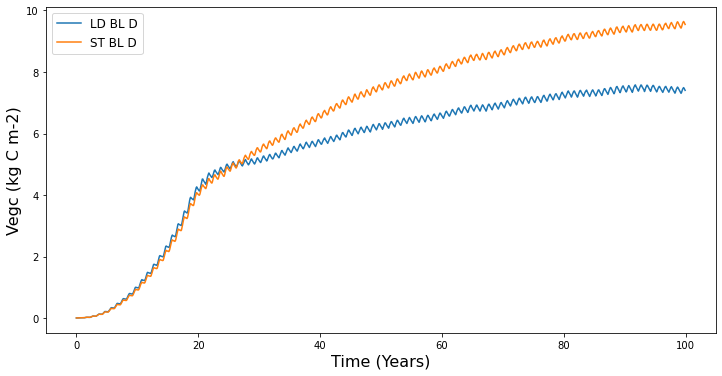

In [6]:
AGB = fates.FATES_VEGC_PF

fig1, axs = plt.subplots(nrows=1,ncols=1, figsize=(12,6))
axs.plot(time, AGB.isel(fates_levpft=0),label = 'LD BL D')  
axs.plot(time, AGB.isel(fates_levpft=1), label = 'ST BL D')      
axs.legend(prop={'size':12})

axs.set_xlabel(r'Time (Years)', fontsize=16)
axs.set_ylabel(r'Vegc (kg C m-2)', fontsize=16)

Text(0, 0.5, 'Number of plants (ha$^{-1}$)')

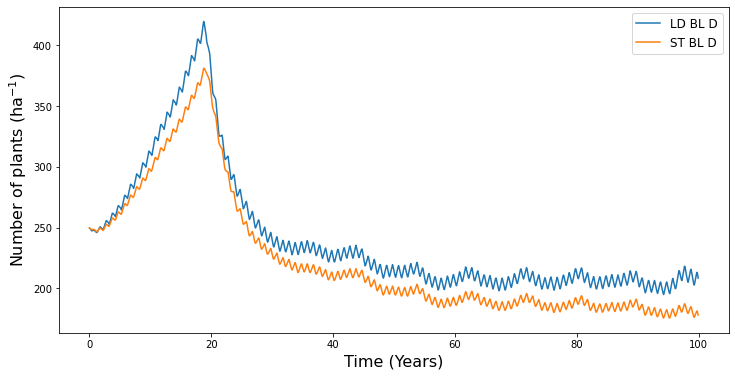

In [7]:
nplant = fates.FATES_NPLANT_PF * 10000

fig1, axs = plt.subplots(nrows=1,ncols=1, figsize=(12,6))
axs.plot(time, nplant.isel(fates_levpft=0),label = 'LD BL D')  
axs.plot(time, nplant.isel(fates_levpft=1), label = 'ST BL D')      
axs.legend(prop={'size':12})

axs.set_xlabel(r'Time (Years)', fontsize=16)
axs.set_ylabel(r'Number of plants (ha$^{-1}$)', fontsize=16)

### Veg C by patch age x PFT

Text(0.5, 1.0, 'Veg C by Patch Age x PFT')

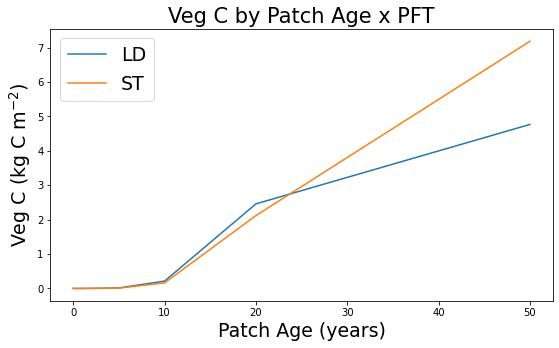

In [14]:
vegc_appf  = fa.appf_to_ap_by_pft(fates.FATES_VEGC_APPF, fates)
vegc_appf  = np.squeeze(vegc_appf.isel(time=slice(1080,1200)).mean(dim='time'))

# set up the page
fig3, ((f3ax0)) = plt.subplots(nrows=1, ncols=1, figsize=(9, 5))

f3ax0.plot(patch_age_bins, vegc_appf.isel(fates_levpft=0),  label = 'LD')
f3ax0.plot(patch_age_bins, vegc_appf.isel(fates_levpft=1),  label = 'ST')
f3ax0.legend(fontsize=19)
f3ax0.set_xlabel('Patch Age (years)', fontsize=19)
f3ax0.set_ylabel(r'Veg C (kg C m$^{-2}$)', fontsize=19)
f3ax0.set_title('Veg C by Patch Age x PFT', fontsize=21)



### Growth rates  

In [9]:
dark = cm.get_cmap('Paired', 12)
colormap = dark(range(12))

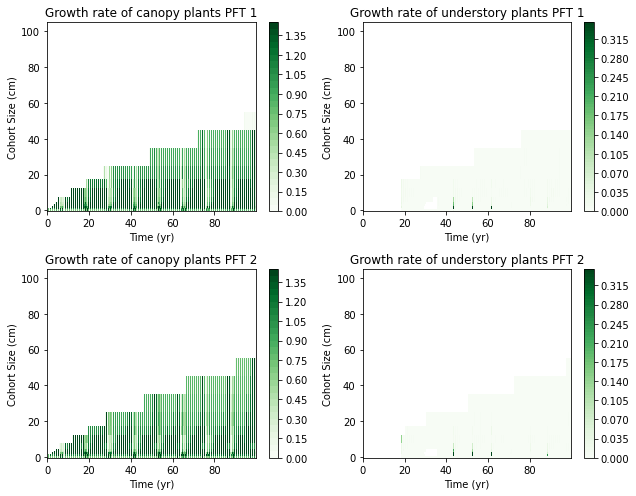

In [10]:
NPLANT_CANOPY_SZPF = szpf_to_scls_by_pft(fates.FATES_NPLANT_CANOPY_SZPF, fates) 
NPLANT_USTORY_SZPF = szpf_to_scls_by_pft(fates.FATES_NPLANT_USTORY_SZPF, fates)

DDBH_CANOPY_SZPF = szpf_to_scls_by_pft(fates.FATES_DDBH_CANOPY_SZPF, fates) * 100 # convert to cm
DDBH_USTORY_SZPF = szpf_to_scls_by_pft(fates.FATES_DDBH_USTORY_SZPF, fates) * 100 # convert to cm

MORT_CANOPY_SZPF = szpf_to_scls_by_pft(fates.FATES_MORTALITY_CANOPY_SZPF, fates)
MORT_USTORY_SZPF = szpf_to_scls_by_pft(fates.FATES_MORTALITY_USTORY_SZPF, fates)

# set up the page
fig3, ((f3ax0, f3ax1), (f3ax2, f3ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(9, 7))

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,1.5, 0.05)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax0.pcolormesh(time, cohort_size_bins, np.squeeze(DDBH_CANOPY_SZPF.isel(fates_levpft=0) / NPLANT_CANOPY_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax0)
f3ax0.set_title(r'Growth rate of canopy plants PFT 1')
f3ax0.set_xlabel('Time (yr)')
f3ax0.set_ylabel('Cohort Size (cm)')

## set up the second plot: growth rate in the understory, units as above
levels = np.arange(0.,0.35, 0.005)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax1.pcolormesh(time, cohort_size_bins, np.squeeze(DDBH_USTORY_SZPF.isel(fates_levpft=0) / NPLANT_USTORY_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax1)
f3ax1.set_title(r'Growth rate of understory plants PFT 1')
f3ax1.set_xlabel('Time (yr)')
f3ax1.set_ylabel('Cohort Size (cm)')

levels = np.arange(0.,1.5, 0.05)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax2.pcolormesh(time, cohort_size_bins, np.squeeze(DDBH_CANOPY_SZPF.isel(fates_levpft=1) / NPLANT_CANOPY_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax2)
f3ax2.set_title(r'Growth rate of canopy plants PFT 2')
f3ax2.set_xlabel('Time (yr)')
f3ax2.set_ylabel('Cohort Size (cm)')

## set up the second plot: growth rate in the understory, units as above
levels = np.arange(0.,0.35, 0.005)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax3.pcolormesh(time, cohort_size_bins, np.squeeze(DDBH_USTORY_SZPF.isel(fates_levpft=1) / NPLANT_USTORY_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax3)
f3ax3.set_title(r'Growth rate of understory plants PFT 2')
f3ax3.set_xlabel('Time (yr)')
f3ax3.set_ylabel('Cohort Size (cm)')

fig3.tight_layout()

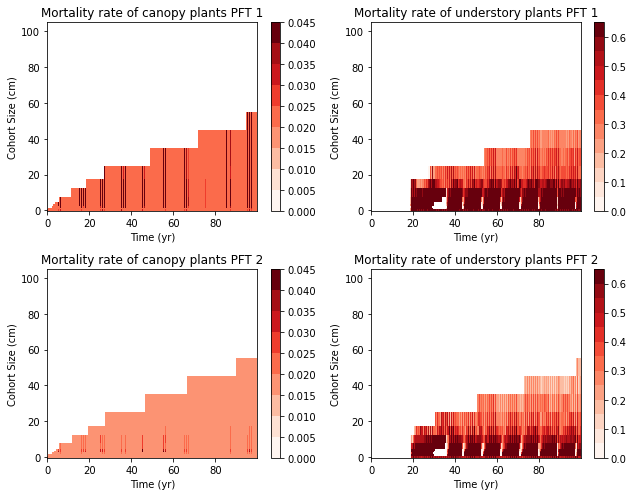

In [11]:
# set up the page
fig3, ((f3ax0, f3ax1), (f3ax2, f3ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(9, 7))

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.05, 0.005)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax0.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_CANOPY_SZPF.isel(fates_levpft=0) / NPLANT_CANOPY_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax0)
f3ax0.set_title(r'Mortality rate of canopy plants PFT 1')
f3ax0.set_xlabel('Time (yr)')
f3ax0.set_ylabel('Cohort Size (cm)')

## set up the second plot: growth rate in the understory, units as above
levels = np.arange(0.,0.7, 0.05)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax1.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_USTORY_SZPF.isel(fates_levpft=0) / NPLANT_USTORY_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax1)
f3ax1.set_title(r'Mortality rate of understory plants PFT 1')
f3ax1.set_xlabel('Time (yr)')
f3ax1.set_ylabel('Cohort Size (cm)')

levels = np.arange(0.,0.05, 0.005)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax2.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_CANOPY_SZPF.isel(fates_levpft=1) / NPLANT_CANOPY_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax2)
f3ax2.set_title(r'Mortality rate of canopy plants PFT 2')
f3ax2.set_xlabel('Time (yr)')
f3ax2.set_ylabel('Cohort Size (cm)')

## set up the second plot: growth rate in the understory, units as above
levels = np.arange(0.,0.7, 0.05)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax3.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_USTORY_SZPF.isel(fates_levpft=1) / NPLANT_USTORY_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax3)
f3ax3.set_title(r'Mortality rate of understory plants PFT 2')
f3ax3.set_xlabel('Time (yr)')
f3ax3.set_ylabel('Cohort Size (cm)')

fig3.tight_layout()

### Mean growth rate by PFT - canopy 

In [12]:
NPLANT_CANOPY_SZPF = szpf_to_scls_by_pft(fates.FATES_NPLANT_CANOPY_SZPF, fates) 
NPLANT_USTORY_SZPF = szpf_to_scls_by_pft(fates.FATES_NPLANT_USTORY_SZPF, fates)

DDBH_CANOPY_SZPF = szpf_to_scls_by_pft(fates.FATES_DDBH_CANOPY_SZPF, fates) * 100 # convert to cm
DDBH_USTORY_SZPF = szpf_to_scls_by_pft(fates.FATES_DDBH_USTORY_SZPF, fates) * 100 # convert to cm

DDBH_CANOPY = DDBH_CANOPY_SZPF.sum(dim='fates_levscls')/NPLANT_CANOPY_SZPF.sum(dim='fates_levscls')
DDBH_CANOPY = DDBH_CANOPY.sel(time=slice("0090-01-01", "0100-01-01")).mean(dim='time')
print(DDBH_CANOPY)

DDBH_USTORY = DDBH_USTORY_SZPF.sum(dim='fates_levscls')/NPLANT_USTORY_SZPF.sum(dim='fates_levscls')
DDBH_USTORY = DDBH_USTORY.sel(time=slice("0090-01-01", "0100-01-01")).mean(dim='time')
print(DDBH_USTORY)

<xarray.DataArray (fates_levpft: 2, lndgrid: 1)>
array([[0.6974473],
       [0.6388714]], dtype=float32)
Coordinates:
  * fates_levpft  (fates_levpft) int32 1 2
Dimensions without coordinates: lndgrid
<xarray.DataArray (fates_levpft: 2, lndgrid: 1)>
array([[0.00071072],
       [0.00066239]], dtype=float32)
Coordinates:
  * fates_levpft  (fates_levpft) int32 1 2
Dimensions without coordinates: lndgrid


### Recruitment

Text(0.02, 0.5, 'Recruitment (ha$^{-1}$ yr$^{-1}$)')

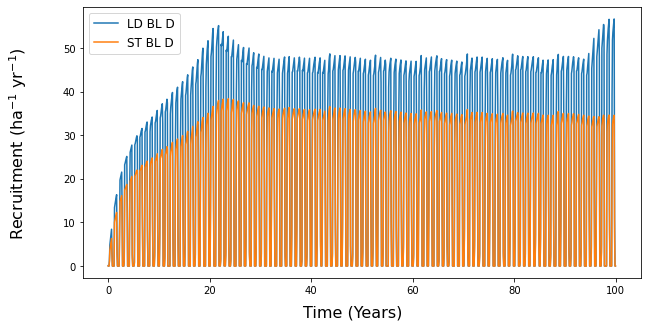

In [13]:
recruit = fates.FATES_RECRUITMENT_PF  * 10000

fig1, axs = plt.subplots(nrows=1,ncols=1, figsize=(10,5))


axs.plot(time, recruit.isel(fates_levpft=0),label = 'LD BL D')  
axs.plot(time, recruit.isel(fates_levpft=1), label = 'ST BL D')      
axs.legend(prop={'size':12})

fig1.supxlabel(r'Time (Years)', fontsize=16)
fig1.supylabel(r'Recruitment (ha$^{-1}$ yr$^{-1}$)', fontsize=16)

In [14]:
# This should be initial density - 
init_density = fates.FATES_RECRUITMENT_PF.sel(time=slice("0090-01-01", "0100-01-01")).mean(dim='time')
init_density

<xarray.DataArray 'FATES_RECRUITMENT_PF' (fates_levpft: 2, lndgrid: 1)>
array([[0.00260754],
       [0.00180959]], dtype=float32)
Coordinates:
  * fates_levpft  (fates_levpft) int32 1 2
Dimensions without coordinates: lndgrid

### Sources of mortality 

In [15]:
nplant = fa.scpf_to_scls_by_pft(fates.FATES_NPLANT_SZPF, fates)
nplant = nplant.sum(dim='fates_levpft')

bmort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_BACKGROUND_SZPF, fates)
bmort = bmort.sum(dim='fates_levpft')
bmort = bmort/nplant

hmort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_HYDRAULIC_SZPF, fates)
hmort = hmort.sum(dim='fates_levpft')
hmort = hmort/nplant

cmort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_CSTARV_SZPF, fates)
cmort = cmort.sum(dim='fates_levpft')
cmort = cmort/nplant

tmort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_TERMINATION_SZPF, fates)
tmort = tmort.sum(dim='fates_levpft')
tmort = tmort/nplant

fmort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_FREEZING_SZPF, fates)
fmort = fmort.sum(dim='fates_levpft')
fmort = fmort/nplant

imort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_IMPACT_SZPF, fates)
imort = imort.sum(dim='fates_levpft')
imort = imort/nplant


In [16]:
print(bmort.shape)

(1200, 1, 17)


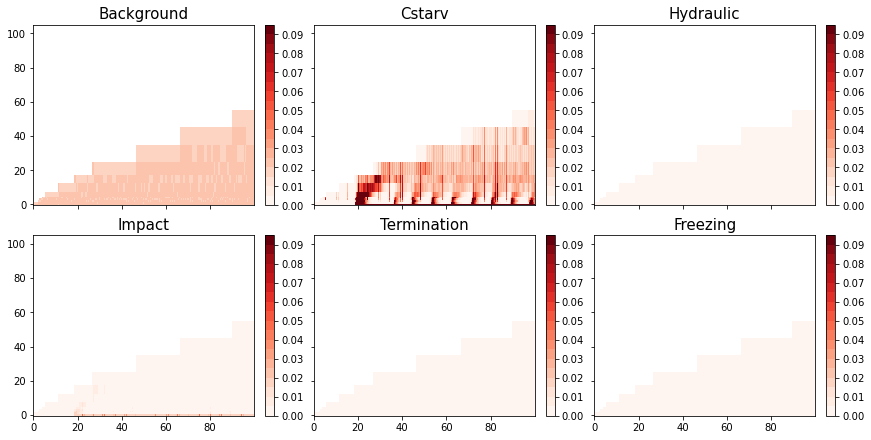

In [17]:
fig1, ((f1ax0,f1ax1,f1ax2),(f1ax3,f1ax4,f1ax5)) = plt.subplots(nrows=2,ncols=3, figsize=(12,6),
                                                              constrained_layout=True,
                                                              sharex=True,sharey=True)

#fig2, ((f2ax0, f2ax1)) = plt.subplots(nrows=1,ncols=2, figsize=(16,5))

## set up the first plot: evolution of AGB of plants of a given size
levels = np.arange(0.,0.1, 0.005)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

im = f1ax0.pcolormesh(time, cohort_size_bins, np.squeeze(bmort).transpose(), cmap=cmap, norm=norm)
f1ax0.set_title(r'Background', fontsize=15)
fig1.colorbar(im, ax=f1ax0)

im = f1ax1.pcolormesh(time, cohort_size_bins, np.squeeze(cmort).transpose(), cmap=cmap, norm=norm)
f1ax1.set_title(r'Cstarv', fontsize=15)
fig1.colorbar(im, ax=f1ax1)

im = f1ax2.pcolormesh(time, cohort_size_bins, np.squeeze(hmort).transpose(), cmap=cmap, norm=norm)
f1ax2.set_title(r'Hydraulic', fontsize=15)
fig1.colorbar(im, ax=f1ax2)

im = f1ax3.pcolormesh(time, cohort_size_bins, np.squeeze(imort).transpose(), cmap=cmap, norm=norm)
f1ax3.set_title(r'Impact', fontsize=15)
fig1.colorbar(im, ax=f1ax3)

im = f1ax4.pcolormesh(time, cohort_size_bins, np.squeeze(tmort).transpose(), cmap=cmap, norm=norm)
f1ax4.set_title(r'Termination', fontsize=15)
fig1.colorbar(im, ax=f1ax4)

im = f1ax5.pcolormesh(time, cohort_size_bins, np.squeeze(fmort).transpose(), cmap=cmap, norm=norm)
f1ax5.set_title(r'Freezing', fontsize=15)
fig1.colorbar(im, ax=f1ax5)

In [18]:
### Compare the forest at 100 years to the SERC data from Piponiot et al data
## Note that SERC is 120 years old

In [19]:
pip_data = pd.read_csv('/global/homes/j/jneedham/plot_data/Piponiot_2022_NewPhyt_AGB_AWP_AWM_standard_size_class.csv')
serc = pip_data['site'] == 'SERC'
serc_data = pip_data[serc]
serc_data_agb = serc_data[serc_data['variable'] == 'AGB']
serc_data_agb

,site,variable,size_class,total,lower_bound,upper_bound
435,SERC,AGB,"[1,5)",1.218,1.110,1.329
436,SERC,AGB,"[5,10)",2.552,2.342,2.765
437,SERC,AGB,"[10,20)",7.663,6.976,8.395
438,SERC,AGB,"[20,30)",14.225,12.790,15.670
439,SERC,AGB,"[30,40)",25.423,22.542,28.535
440,SERC,AGB,"[40,50)",34.570,29.979,39.270
441,SERC,AGB,"[50,100)",171.022,154.802,186.948
442,SERC,AGB,"[100,200)",16.575,8.451,25.329


<xarray.DataArray 'FATES_VEGC_ABOVEGROUND_SZ' (fates_levscls: 16)>
array([6.0104933e-03, 1.2689826e-02, 3.5238013e-02, 6.5702222e-02,
       1.3145816e+00, 3.8584626e+00, 6.6960139e+00, 1.9641872e+01,
       1.9270632e+01, 1.5623289e+01, 3.5101234e+01, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
      dtype=float32)
Coordinates:
  * fates_levscls  (fates_levscls) float32 1.0 2.0 3.0 4.0 ... 80.0 90.0 100.0


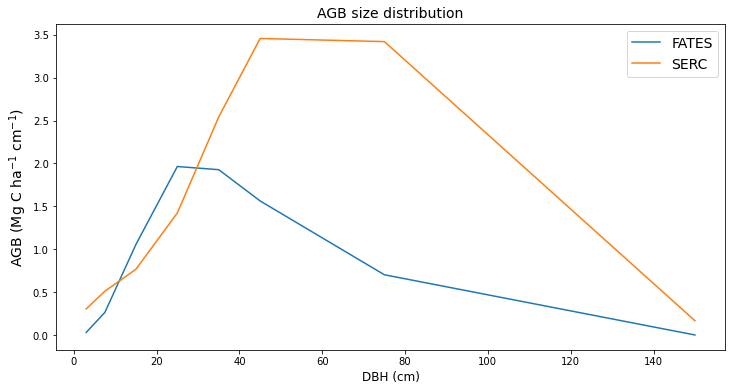

In [20]:
AGB_SZ = fates.FATES_VEGC_ABOVEGROUND_SZ * 10000 # m2 to ha

agb = AGB_SZ.sel(time=slice('0099-01-01','0100-01-01')).mean(dim='time') * 0.001  # kg to Mg
agb = np.squeeze(agb)

# remove the first size bin
fates_agb = np.squeeze(agb[1:,])
print(fates_agb)
# combine the 1-5 bins into a single bin
fates_agb = fates_agb.groupby_bins('fates_levscls', bins=np.array([1,5,10,20,30,40,50,100,200]), right=False).sum()

new_size_bins = np.array([1,5,10,20,30,40,50,100,200])
sizebin_mids = np.array([3, 7.5, 15, 25, 35, 45, 75, 150])
sizebin_widths = new_size_bins[1:]-new_size_bins[:-1]


fig2, ((f2ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f2ax0.plot(sizebin_mids, fates_agb/sizebin_widths,  label = 'FATES')
f2ax0.plot(sizebin_mids, serc_data_agb['total']/sizebin_widths, label='SERC')

f2ax0.set_title(r'AGB size distribution', fontsize = 14)
f2ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$ cm$^{-1}$)', fontsize = 14)
f2ax0.set_xlabel(r'DBH (cm)', fontsize = 12)    

f2ax0.legend(fontsize=14)
# f2ax0.set_yscale('log')
# #f2ax0.set_xscale('log')